In [1]:
# ============================================================
# CELL 1 — Seeds + Setup
# ============================================================
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PREPROCESSED_DIR = "/kaggle/input/datasets/iftekharuddin27/preprocessed-datasets"
OUTPUT_DIR = "/kaggle/working/"

import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
all_results = []
print(f"Device: {device}")
print("Imports loaded!")

Device: cuda
Imports loaded!


In [2]:
# ============================================================
# CELL 2 — Load ALL splits including test
# ============================================================
en_train = pd.read_csv(f"{PREPROCESSED_DIR}/en_train.csv")
en_val   = pd.read_csv(f"{PREPROCESSED_DIR}/en_val.csv")
en_test  = pd.read_csv(f"{PREPROCESSED_DIR}/en_test.csv")   # <-- added

bn_train = pd.read_csv(f"{PREPROCESSED_DIR}/bn_train.csv")
bn_val   = pd.read_csv(f"{PREPROCESSED_DIR}/bn_val.csv")
bn_test  = pd.read_csv(f"{PREPROCESSED_DIR}/bn_test.csv")   # <-- added

for df in [en_train, en_val, en_test, bn_train, bn_val, bn_test]:
    df['text_clean'] = df['text_clean'].fillna('')

y_en_train = en_train['class'].values
y_en_val   = en_val['class'].values
y_en_test  = en_test['class'].values                         # <-- added

y_bn_train = bn_train['label'].values
y_bn_val   = bn_val['label'].values
y_bn_test  = bn_test['label'].values                         # <-- added

print(f"English: Train={len(en_train):,} Val={len(en_val):,} Test={len(en_test):,}")
print(f"Bangla:  Train={len(bn_train):,} Val={len(bn_val):,} Test={len(bn_test):,}")

English: Train=83,455 Val=10,432 Test=10,432
Bangla:  Train=67,009 Val=8,376 Test=8,377


In [3]:
# ============================================================
# CELL 3 — Evaluate helper (unchanged)
# ============================================================
def evaluate_model(model_name, y_true, y_pred, dataset_name, save_cm=True):
    acc      = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    report   = classification_report(y_true, y_pred,
                   target_names=list(CLASS_NAMES.values()), output_dict=True)

    print(f"\n{'='*60}")
    print(f"{model_name} - {dataset_name}")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=list(CLASS_NAMES.values())))

    if save_cm:
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=CLASS_NAMES.values(),
                    yticklabels=CLASS_NAMES.values(), ax=ax)
        ax.set_title(f'{model_name} - {dataset_name}')
        ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}cm_{model_name}_{dataset_name}.png"
                    .replace(' ','_'), dpi=100)
        plt.show()

    result = {'model': model_name, 'dataset': dataset_name,
              'accuracy': round(acc,4), 'macro_f1': round(f1_macro,4)}
    for cls_name in CLASS_NAMES.values():
        if cls_name in report:
            result[f'{cls_name}_f1'] = round(report[cls_name]['f1-score'], 4)
    all_results.append(result)
    return result

In [4]:
# ============================================================
# CELL 4 — Feature engineering (unchanged from your notebook)
# ============================================================
def extract_english_features(df):
    texts = df['text_clean'].fillna('')
    features = pd.DataFrame()
    features['char_count']        = texts.str.len()
    features['word_count']        = texts.str.split().str.len().fillna(0)
    features['avg_word_len']      = texts.apply(
        lambda t: np.mean([len(w) for w in str(t).split()]) if str(t).split() else 0)
    features['exclamation_count'] = texts.str.count('!')
    features['question_count']    = texts.str.count(r'\?')
    features['ellipsis_count']    = texts.str.count(r'\.\.\.')
    features['quote_count']       = texts.str.count('"') + texts.str.count("'")
    features['caps_word_count']   = (df['text'].fillna('') if 'text' in df.columns
                                     else texts).apply(
        lambda t: len(re.findall(r'\b[A-Z]{2,}\b', str(t))))
    features['has_profanity']     = texts.apply(
        lambda t: int(any(w in str(t).split() for w in
            {'shit','fuck','fucking','bitch','ass','damn','nigga','nigger',
             'crap','idiot','stupid','stfu','wtf'})))
    features['negation_count']    = texts.apply(
        lambda t: len(re.findall(
            r"\b(not|no|never|nothing|don't|doesn't|didn't|won't|can't)\b",
            str(t), re.IGNORECASE)))
    features['unique_word_ratio'] = texts.apply(
        lambda t: len(set(str(t).split())) / max(len(str(t).split()), 1))
    return features

def extract_bangla_features(df):
    texts = df['text_clean'].fillna('')
    features = pd.DataFrame()
    features['char_count']          = texts.str.len()
    features['word_count']          = texts.str.split().str.len().fillna(0)
    features['avg_word_len']        = texts.apply(
        lambda t: np.mean([len(w) for w in str(t).split()]) if str(t).split() else 0)
    features['exclamation_count']   = texts.str.count('!')
    features['question_count']      = texts.str.count(r'\?')
    features['bangla_danda_count']  = texts.str.count('।')
    features['english_word_count']  = texts.apply(
        lambda t: len(re.findall(r'[a-zA-Z]{2,}', str(t))))
    features['repeated_chars']      = texts.apply(
        lambda t: len(re.findall(r'(.)\1{2,}', str(t))))
    features['unique_word_ratio']   = texts.apply(
        lambda t: len(set(str(t).split())) / max(len(str(t).split()), 1))
    return features

print("Extracting features...")
en_train_feat = extract_english_features(en_train)
en_val_feat   = extract_english_features(en_val)
en_test_feat  = extract_english_features(en_test)   # <-- added

bn_train_feat = extract_bangla_features(bn_train)
bn_val_feat   = extract_bangla_features(bn_val)
bn_test_feat  = extract_bangla_features(bn_test)    # <-- added
print("Done.")

Extracting features...
Done.


In [5]:
# ============================================================
# CELL 5 — TF-IDF + combine features
# ============================================================
print("Building TF-IDF features...")

# English
tfidf_en_word = TfidfVectorizer(max_features=50000, ngram_range=(1,3),
                                 sublinear_tf=True, min_df=2, max_df=0.95)
tfidf_en_char = TfidfVectorizer(max_features=30000, ngram_range=(3,5),
                                 sublinear_tf=True, min_df=2, max_df=0.95,
                                 analyzer='char_wb')
X_en_tr_word = tfidf_en_word.fit_transform(en_train['text_clean'])
X_en_tr_char = tfidf_en_char.fit_transform(en_train['text_clean'])
X_en_va_word = tfidf_en_word.transform(en_val['text_clean'])
X_en_va_char = tfidf_en_char.transform(en_val['text_clean'])
X_en_te_word = tfidf_en_word.transform(en_test['text_clean'])   # <-- added
X_en_te_char = tfidf_en_char.transform(en_test['text_clean'])   # <-- added

scaler_en    = StandardScaler()
X_en_tr_eng  = scaler_en.fit_transform(en_train_feat.values)
X_en_va_eng  = scaler_en.transform(en_val_feat.values)
X_en_te_eng  = scaler_en.transform(en_test_feat.values)         # <-- added

X_en_train = hstack([X_en_tr_word, X_en_tr_char, csr_matrix(X_en_tr_eng)])
X_en_val   = hstack([X_en_va_word, X_en_va_char, csr_matrix(X_en_va_eng)])
X_en_test  = hstack([X_en_te_word, X_en_te_char, csr_matrix(X_en_te_eng)])  # <-- added

# Bangla
tfidf_bn_word = TfidfVectorizer(max_features=50000, ngram_range=(1,3),
                                 sublinear_tf=True, min_df=2, max_df=0.95)
tfidf_bn_char = TfidfVectorizer(max_features=30000, ngram_range=(3,6),
                                 sublinear_tf=True, min_df=2, max_df=0.95,
                                 analyzer='char_wb')
X_bn_tr_word = tfidf_bn_word.fit_transform(bn_train['text_clean'])
X_bn_tr_char = tfidf_bn_char.fit_transform(bn_train['text_clean'])
X_bn_va_word = tfidf_bn_word.transform(bn_val['text_clean'])
X_bn_va_char = tfidf_bn_char.transform(bn_val['text_clean'])
X_bn_te_word = tfidf_bn_word.transform(bn_test['text_clean'])   # <-- added
X_bn_te_char = tfidf_bn_char.transform(bn_test['text_clean'])   # <-- added

scaler_bn    = StandardScaler()
X_bn_tr_eng  = scaler_bn.fit_transform(bn_train_feat.values)
X_bn_va_eng  = scaler_bn.transform(bn_val_feat.values)
X_bn_te_eng  = scaler_bn.transform(bn_test_feat.values)         # <-- added

X_bn_train = hstack([X_bn_tr_word, X_bn_tr_char, csr_matrix(X_bn_tr_eng)])
X_bn_val   = hstack([X_bn_va_word, X_bn_va_char, csr_matrix(X_bn_va_eng)])
X_bn_test  = hstack([X_bn_te_word, X_bn_te_char, csr_matrix(X_bn_te_eng)])  # <-- added

cw_bn = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_bn_train)
print(f"English combined: {X_en_train.shape}")
print(f"Bangla  combined: {X_bn_train.shape}")

Building TF-IDF features...
English combined: (83455, 80011)
Bangla  combined: (67009, 80009)


LOGISTIC REGRESSION

--- VALIDATION ---

LR - English-VAL
Accuracy: 0.7819
Macro F1: 0.7819
              precision    recall  f1-score   support

 Non-hateful       0.73      0.68      0.70      3470
     Hateful       0.89      0.84      0.86      3485
   Sarcastic       0.73      0.83      0.78      3477

    accuracy                           0.78     10432
   macro avg       0.79      0.78      0.78     10432
weighted avg       0.79      0.78      0.78     10432



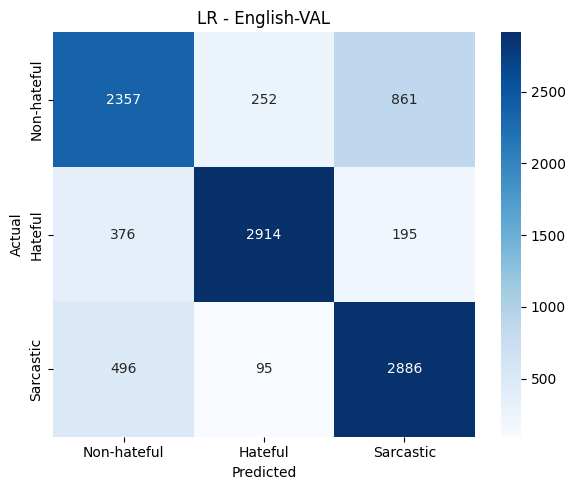


LR - Bangla-VAL
Accuracy: 0.7640
Macro F1: 0.7558
              precision    recall  f1-score   support

 Non-hateful       0.83      0.70      0.76      4140
     Hateful       0.87      0.86      0.86      2560
   Sarcastic       0.55      0.77      0.64      1676

    accuracy                           0.76      8376
   macro avg       0.75      0.78      0.76      8376
weighted avg       0.79      0.76      0.77      8376



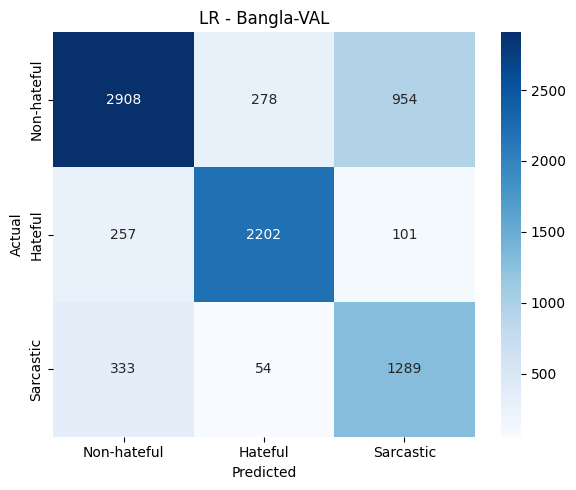


--- TEST ---

LR - English-TEST
Accuracy: 0.7918
Macro F1: 0.7920
              precision    recall  f1-score   support

 Non-hateful       0.73      0.70      0.72      3470
     Hateful       0.90      0.84      0.87      3486
   Sarcastic       0.75      0.83      0.79      3476

    accuracy                           0.79     10432
   macro avg       0.79      0.79      0.79     10432
weighted avg       0.79      0.79      0.79     10432



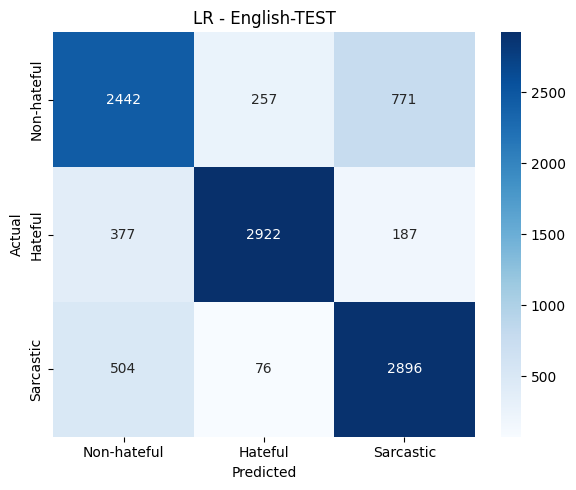


LR - Bangla-TEST
Accuracy: 0.7658
Macro F1: 0.7583
              precision    recall  f1-score   support

 Non-hateful       0.83      0.70      0.76      4140
     Hateful       0.87      0.86      0.86      2560
   Sarcastic       0.56      0.78      0.65      1677

    accuracy                           0.77      8377
   macro avg       0.75      0.78      0.76      8377
weighted avg       0.79      0.77      0.77      8377



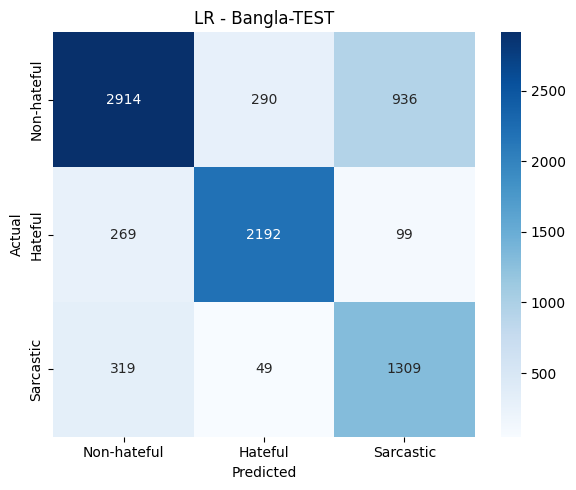

{'model': 'LR',
 'dataset': 'Bangla-TEST',
 'accuracy': 0.7658,
 'macro_f1': 0.7583,
 'Non-hateful_f1': 0.7626,
 'Hateful_f1': 0.8611,
 'Sarcastic_f1': 0.6511}

In [6]:
# ============================================================
# CELL 6 — Train LR + evaluate on val AND test
# ============================================================
print("="*70)
print("LOGISTIC REGRESSION")
print("="*70)

# Train
lr_en = LogisticRegression(max_iter=2000, C=5.0, solver='saga',
                            random_state=42, n_jobs=-1)
lr_en.fit(X_en_train, y_en_train)

lr_bn = LogisticRegression(max_iter=2000, C=5.0, solver='saga',
                            class_weight='balanced', random_state=42, n_jobs=-1)
lr_bn.fit(X_bn_train, y_bn_train)

# Val results (confirm same as before)
print("\n--- VALIDATION ---")
evaluate_model("LR", y_en_val,  lr_en.predict(X_en_val), "English-VAL")
evaluate_model("LR", y_bn_val,  lr_bn.predict(X_bn_val), "Bangla-VAL")

# Test results (the new numbers)
print("\n--- TEST ---")
evaluate_model("LR", y_en_test, lr_en.predict(X_en_test), "English-TEST")
evaluate_model("LR", y_bn_test, lr_bn.predict(X_bn_test), "Bangla-TEST")

In [7]:
# ============================================================
# CELL 7 — BiLSTM architecture + training function
# ============================================================
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_classes=3, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                            bidirectional=True, dropout=dropout, num_layers=2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embeds = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embeds)
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden_cat))

class SimpleTokenizer:
    def __init__(self, max_vocab=30000):
        self.max_vocab = max_vocab
        self.word2idx  = {'<PAD>': 0, '<UNK>': 1}
    def fit(self, texts):
        from collections import Counter
        counts = Counter()
        for t in texts: counts.update(str(t).split())
        for w, _ in counts.most_common(self.max_vocab - 2):
            self.word2idx[w] = len(self.word2idx)
        print(f"Vocab size: {len(self.word2idx)}")
        return self
    def encode(self, text, max_len=128):
        tokens = [self.word2idx.get(w, 1) for w in str(text).split()]
        return tokens[:max_len]

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.data = [(tokenizer.encode(t, max_len), l)
                     for t, l in zip(texts, labels)]
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        tokens, label = self.data[idx]
        return torch.tensor(tokens, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def collate_fn(batch):
    texts, labels = zip(*batch)
    return pad_sequence(texts, batch_first=True, padding_value=0), torch.stack(labels)

def train_bilstm(model, train_loader, val_loader, y_val,
                 model_name, dataset_name, epochs=10, class_weights=None):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = (nn.CrossEntropyLoss(
                     weight=torch.tensor(class_weights, dtype=torch.float).to(device))
                 if class_weights is not None else nn.CrossEntropyLoss())
    best_f1, best_state = 0, None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        preds = []
        with torch.no_grad():
            for bx, _ in val_loader:
                preds.extend(model(bx.to(device)).argmax(dim=1).cpu().numpy())
        f1 = f1_score(y_val, preds, average='macro')
        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if (epoch+1) % 3 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}"
                  f" - Val F1: {f1:.4f}")

    model.load_state_dict(best_state)  # restore best
    print(f"Best val F1: {best_f1:.4f}")
    return model

BiLSTM — ENGLISH
Vocab size: 30000
  Epoch 1/10 - Loss: 0.7430 - Val F1: 0.7295
  Epoch 3/10 - Loss: 0.5043 - Val F1: 0.7811
  Epoch 6/10 - Loss: 0.3787 - Val F1: 0.8116
  Epoch 9/10 - Loss: 0.3030 - Val F1: 0.8101
Best val F1: 0.8144

BiLSTM - English-VAL
Accuracy: 0.8144
Macro F1: 0.8144
              precision    recall  f1-score   support

 Non-hateful       0.77      0.73      0.75      3470
     Hateful       0.90      0.85      0.87      3485
   Sarcastic       0.78      0.86      0.82      3477

    accuracy                           0.81     10432
   macro avg       0.82      0.81      0.81     10432
weighted avg       0.82      0.81      0.81     10432



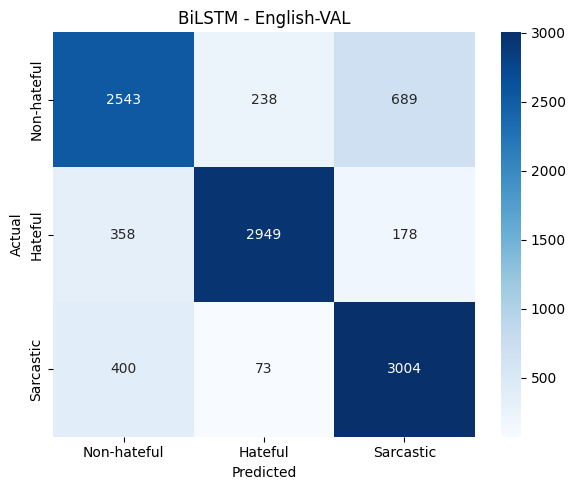


BiLSTM - English-TEST
Accuracy: 0.8239
Macro F1: 0.8241
              precision    recall  f1-score   support

 Non-hateful       0.78      0.76      0.77      3470
     Hateful       0.90      0.86      0.88      3486
   Sarcastic       0.80      0.85      0.82      3476

    accuracy                           0.82     10432
   macro avg       0.83      0.82      0.82     10432
weighted avg       0.83      0.82      0.82     10432



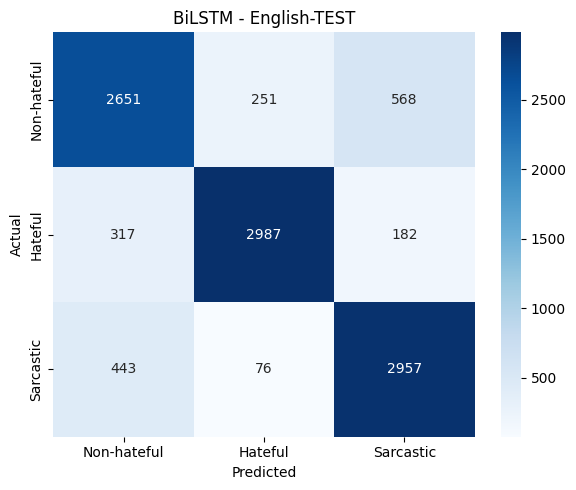

{'model': 'BiLSTM',
 'dataset': 'English-TEST',
 'accuracy': 0.8239,
 'macro_f1': 0.8241,
 'Non-hateful_f1': 0.7705,
 'Hateful_f1': 0.8785,
 'Sarcastic_f1': 0.8233}

In [8]:
# ============================================================
# CELL 8 — Train BiLSTM English + val & test evaluation
# ============================================================
print("="*70)
print("BiLSTM — ENGLISH")
print("="*70)

tok_en = SimpleTokenizer(max_vocab=30000)
tok_en.fit(en_train['text_clean'].values)

train_loader_en = DataLoader(
    TextDataset(en_train['text_clean'].values, y_en_train, tok_en),
    batch_size=128, shuffle=True, collate_fn=collate_fn)
val_loader_en = DataLoader(
    TextDataset(en_val['text_clean'].values, y_en_val, tok_en),
    batch_size=256, shuffle=False, collate_fn=collate_fn)
test_loader_en = DataLoader(
    TextDataset(en_test['text_clean'].values, y_en_test, tok_en),
    batch_size=256, shuffle=False, collate_fn=collate_fn)

bilstm_en = train_bilstm(
    BiLSTMClassifier(len(tok_en.word2idx)),
    train_loader_en, val_loader_en, y_en_val,
    "BiLSTM", "English")

# Val (confirm)
bilstm_en.eval()
val_preds = []
with torch.no_grad():
    for bx, _ in val_loader_en:
        val_preds.extend(bilstm_en(bx.to(device)).argmax(dim=1).cpu().numpy())
evaluate_model("BiLSTM", y_en_val, val_preds, "English-VAL")

# Test (new)
test_preds = []
with torch.no_grad():
    for bx, _ in test_loader_en:
        test_preds.extend(bilstm_en(bx.to(device)).argmax(dim=1).cpu().numpy())
evaluate_model("BiLSTM", y_en_test, test_preds, "English-TEST")

BiLSTM — BANGLA
Vocab size: 30000
  Epoch 1/10 - Loss: 0.8174 - Val F1: 0.6615
  Epoch 3/10 - Loss: 0.5703 - Val F1: 0.7413
  Epoch 6/10 - Loss: 0.4346 - Val F1: 0.7537
  Epoch 9/10 - Loss: 0.3502 - Val F1: 0.7516
Best val F1: 0.7631

BiLSTM - Bangla-VAL
Accuracy: 0.7802
Macro F1: 0.7631
              precision    recall  f1-score   support

 Non-hateful       0.80      0.78      0.79      4140
     Hateful       0.86      0.87      0.86      2560
   Sarcastic       0.62      0.66      0.64      1676

    accuracy                           0.78      8376
   macro avg       0.76      0.77      0.76      8376
weighted avg       0.78      0.78      0.78      8376



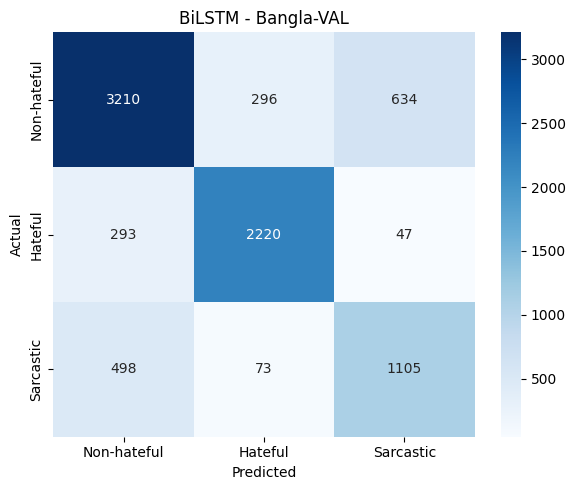


BiLSTM - Bangla-TEST
Accuracy: 0.7775
Macro F1: 0.7616
              precision    recall  f1-score   support

 Non-hateful       0.81      0.76      0.78      4140
     Hateful       0.84      0.88      0.86      2560
   Sarcastic       0.62      0.67      0.65      1677

    accuracy                           0.78      8377
   macro avg       0.76      0.77      0.76      8377
weighted avg       0.78      0.78      0.78      8377



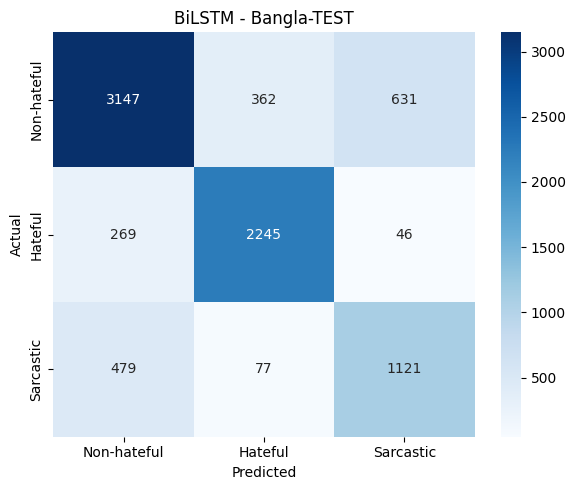

{'model': 'BiLSTM',
 'dataset': 'Bangla-TEST',
 'accuracy': 0.7775,
 'macro_f1': 0.7616,
 'Non-hateful_f1': 0.7833,
 'Hateful_f1': 0.8562,
 'Sarcastic_f1': 0.6452}

In [9]:
# ============================================================
# CELL 9 — Train BiLSTM Bangla + val & test evaluation
# ============================================================
print("="*70)
print("BiLSTM — BANGLA")
print("="*70)

tok_bn = SimpleTokenizer(max_vocab=30000)
tok_bn.fit(bn_train['text_clean'].values)

train_loader_bn = DataLoader(
    TextDataset(bn_train['text_clean'].values, y_bn_train, tok_bn),
    batch_size=128, shuffle=True, collate_fn=collate_fn)
val_loader_bn = DataLoader(
    TextDataset(bn_val['text_clean'].values, y_bn_val, tok_bn),
    batch_size=256, shuffle=False, collate_fn=collate_fn)
test_loader_bn = DataLoader(
    TextDataset(bn_test['text_clean'].values, y_bn_test, tok_bn),
    batch_size=256, shuffle=False, collate_fn=collate_fn)

bilstm_bn = train_bilstm(
    BiLSTMClassifier(len(tok_bn.word2idx)),
    train_loader_bn, val_loader_bn, y_bn_val,
    "BiLSTM", "Bangla",
    class_weights=cw_bn)

# Val (confirm)
bilstm_bn.eval()
val_preds = []
with torch.no_grad():
    for bx, _ in val_loader_bn:
        val_preds.extend(bilstm_bn(bx.to(device)).argmax(dim=1).cpu().numpy())
evaluate_model("BiLSTM", y_bn_val, val_preds, "Bangla-VAL")

# Test (new)
test_preds = []
with torch.no_grad():
    for bx, _ in test_loader_bn:
        test_preds.extend(bilstm_bn(bx.to(device)).argmax(dim=1).cpu().numpy())
evaluate_model("BiLSTM", y_bn_test, test_preds, "Bangla-TEST")

In [10]:
# ============================================================
# CELL 10 — Final summary table
# ============================================================
results_df = pd.DataFrame(all_results)
print("\n" + "="*60)
print("COMPLETE RESULTS SUMMARY")
print("="*60)
print(results_df[['model','dataset','accuracy','macro_f1',
                   'Sarcastic_f1']].to_string(index=False))
results_df.to_csv(f"{OUTPUT_DIR}ml_dl_results_summary.csv", index=False)
print("\nSaved to /kaggle/working/ml_dl_results_summary.csv")


COMPLETE RESULTS SUMMARY
 model      dataset  accuracy  macro_f1  Sarcastic_f1
    LR  English-VAL    0.7819    0.7819        0.7780
    LR   Bangla-VAL    0.7640    0.7558        0.6413
    LR English-TEST    0.7918    0.7920        0.7902
    LR  Bangla-TEST    0.7658    0.7583        0.6511
BiLSTM  English-VAL    0.8144    0.8144        0.8176
BiLSTM English-TEST    0.8239    0.8241        0.8233
BiLSTM   Bangla-VAL    0.7802    0.7631        0.6384
BiLSTM  Bangla-TEST    0.7775    0.7616        0.6452

Saved to /kaggle/working/ml_dl_results_summary.csv
